In [1]:
!pip install -q scanpy leidenalg igraph pydeseq2 gseapy pandas==2.2.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 8.5 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

from scipy.io import mmread
from scipy.sparse import csr_matrix, vstack

print("Setup working")

Setup working


In [2]:
!wget -q \
"https://ftp.ncbi.nlm.nih.gov/geo/series/GSE221nnn/GSE221042/suppl/GSE221042_data.mtx.gz" \
-O expression.mtx.gz

!wget -q \
"https://ftp.ncbi.nlm.nih.gov/geo/series/GSE221nnn/GSE221042/suppl/GSE221042_genes.csv.gz" \
-O genes.csv.gz

!wget -q \
"https://ftp.ncbi.nlm.nih.gov/geo/series/GSE221nnn/GSE221042/suppl/GSE221042_sample_annotations.csv.gz" \
-O metadata.csv.gz

print("Downloaded")

Downloaded


In [3]:
metadata = pd.read_csv("metadata.csv.gz")
genes = pd.read_csv("genes.csv.gz", header=None)
X_raw = mmread("expression.mtx.gz").tocsr()

print("Expression matrix:", X_raw.shape)
print("Metadata:", metadata.shape)
print("Genes:", genes.shape)

Expression matrix: (70973, 28261)
Metadata: (70973, 5)
Genes: (28261, 2)


## 1. Preprocessing and retinal cell-state reconstruction

The public processed count matrix was loaded together with donor/disease metadata. Gene symbols were cleaned, counts were normalized for exploratory single-cell analysis, and nuclei were represented using PCA, a nearest-neighbor graph, UMAP, and Leiden clustering.

In [5]:
adata = sc.AnnData(X=X_raw.copy())

adata.var_names = genes[1].str.split(" ").str[0].values
adata.var_names_make_unique()

adata.obs = metadata.copy()

print(adata)
print("\nConditions:")
print(adata.obs["condition_labels"].value_counts())

AnnData object with n_obs × n_vars = 70973 × 28261
    obs: 'Unnamed: 0', 'sample_labels', 'condition_labels', 'n_genes_by_counts', 'total_counts'

Conditions:
condition_labels
wAMD       29424
dAMD       24151
Healthy    17398
Name: count, dtype: int64


/usr/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [6]:
adata = sc.AnnData(X=X_raw.copy())

# Clean human-readable gene symbols
adata.var_names = genes[1].str.split(" ").str[0].values
adata.var_names_make_unique()

# Attach donor and disease metadata
adata.obs = metadata.copy()

print(adata)
print("\nConditions:")
print(adata.obs["condition_labels"].value_counts())

AnnData object with n_obs × n_vars = 70973 × 28261
    obs: 'Unnamed: 0', 'sample_labels', 'condition_labels', 'n_genes_by_counts', 'total_counts'

Conditions:
condition_labels
wAMD       29424
dAMD       24151
Healthy    17398
Name: count, dtype: int64


/usr/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [7]:
# Normalize for exploratory single-cell analysis
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Identify informative genes
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000
)

# Dimensionality reduction
sc.tl.pca(
    adata,
    n_comps=50,
    use_highly_variable=True
)

# Cell-cell similarity graph
sc.pp.neighbors(
    adata,
    n_neighbors=15,
    n_pcs=30
)

# 2D visualization
sc.tl.umap(adata)

# Unsupervised clustering
sc.tl.leiden(
    adata,
    resolution=0.5
)

print("Number of Leiden clusters:", adata.obs["leiden"].nunique())

/tmp/ipykernel_1193/1652556313.py:12: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(
/tmp/ipykernel_1193/1652556313.py:29: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


Number of Leiden clusters: 30


In [8]:
muller_markers = [
    "RLBP1",
    "GLUL",
    "SLC1A3",
    "RGR"
]

sc.tl.score_genes(
    adata,
    gene_list=muller_markers,
    score_name="muller_score"
)

cluster_scores = (
    adata.obs
    .groupby("leiden", observed=True)["muller_score"]
    .mean()
    .sort_values(ascending=False)
)

display(cluster_scores.head(10))

best_cluster = cluster_scores.index[0]

print("\nHighest-scoring candidate Müller cluster:", best_cluster)
print(
    "Number of nuclei:",
    (adata.obs["leiden"] == best_cluster).sum()
)

,muller_score
leiden,
4,1.950962
26,1.347848
17,1.099089
28,0.866137
7,0.697562
18,0.132876
25,0.035520
6,-0.074605
1,-0.103385



Highest-scoring candidate Müller cluster: 4
Number of nuclei: 4594


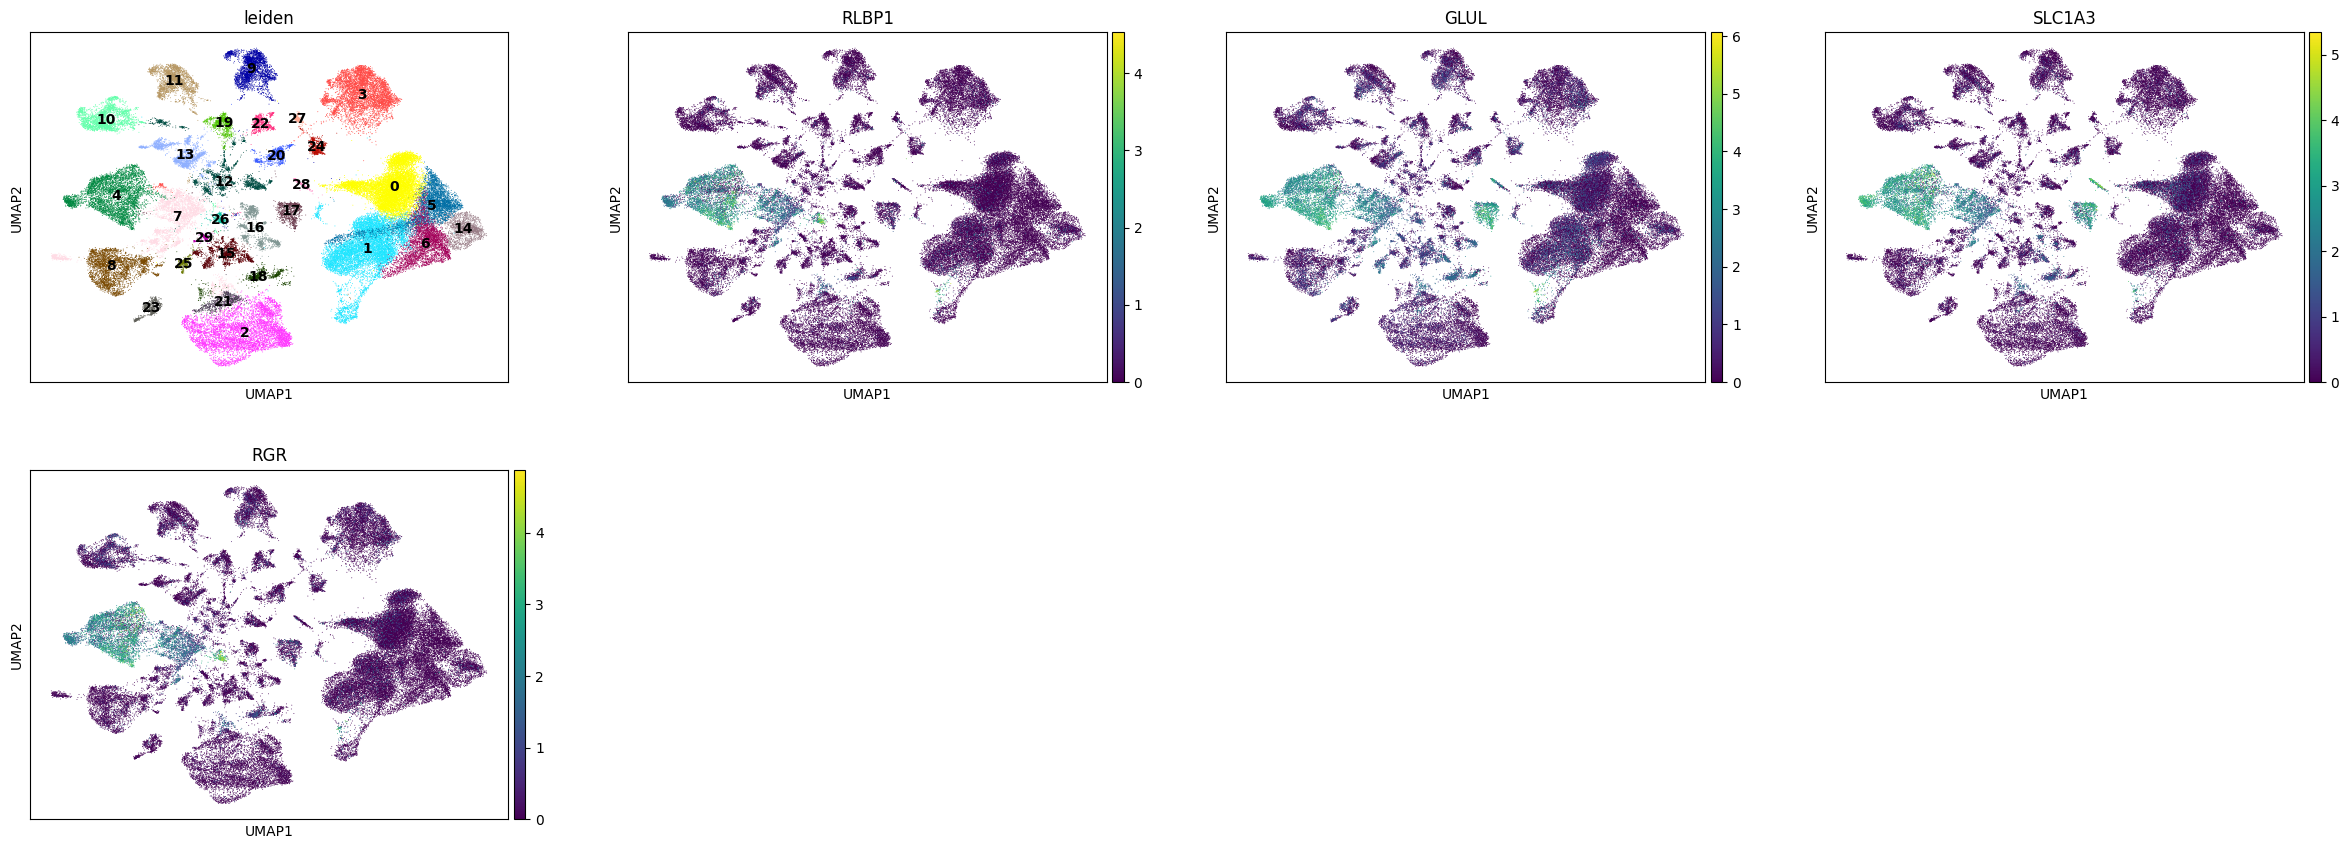

In [9]:
sc.pl.umap(
    adata,
    color=[
        "leiden",
        "RLBP1",
        "GLUL",
        "SLC1A3",
        "RGR"
    ],
    legend_loc="on data"
)

## 2. Identification of candidate Müller glia

A candidate Müller-glial population was identified by combining unsupervised Leiden clustering with expression of established Müller-associated markers including RLBP1, GLUL, SLC1A3 and RGR. Cluster identity was subsequently checked using cluster-specific differential expression rather than relying on a single marker.

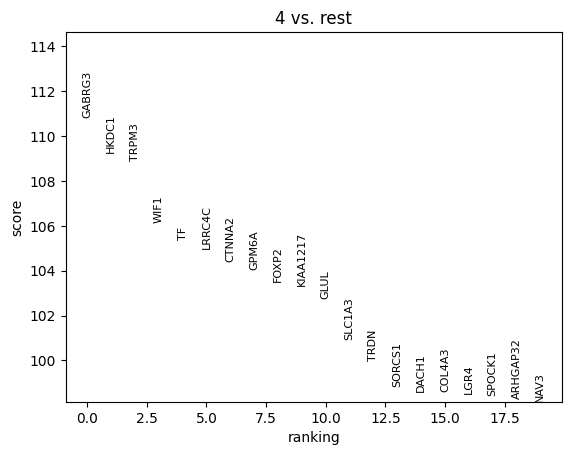

In [10]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    groups=["4"],
    reference="rest",
    method="wilcoxon"
)

sc.pl.rank_genes_groups(
    adata,
    groups=["4"],
    n_genes=20
)

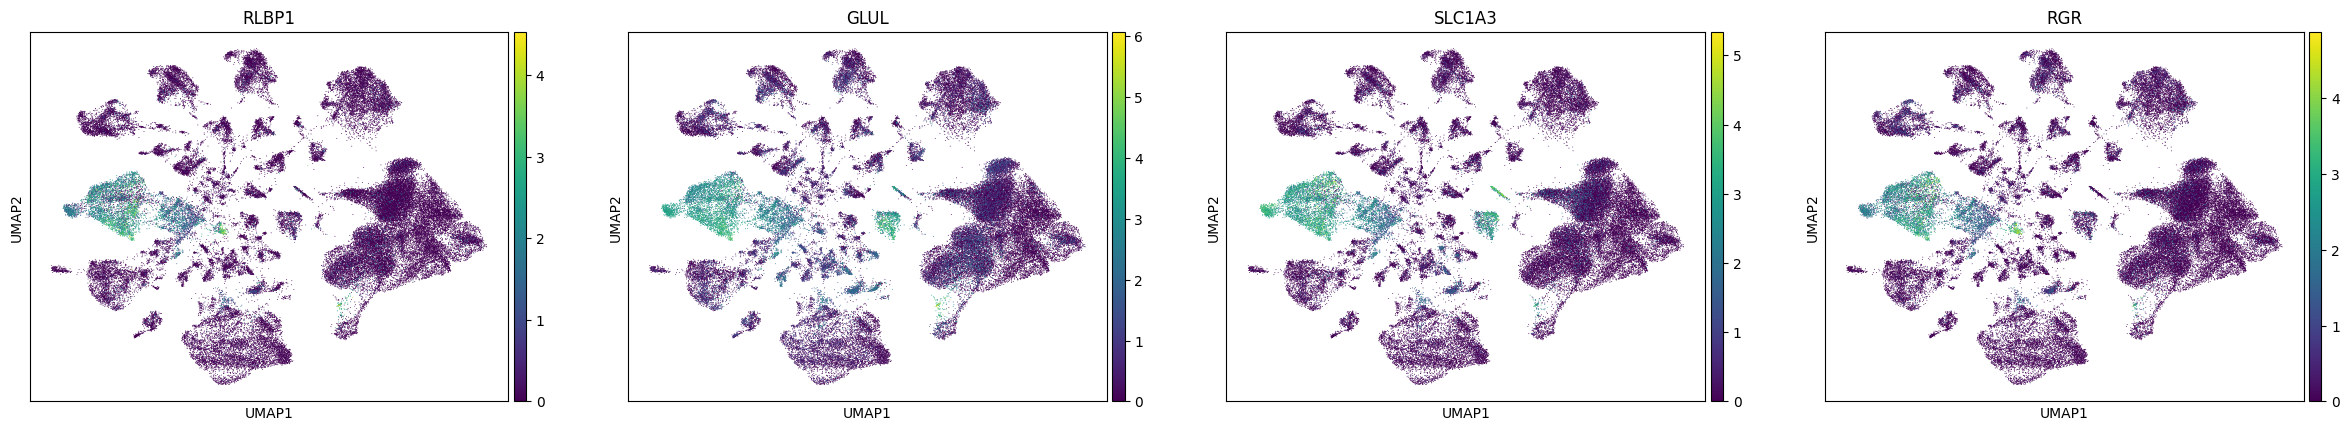

In [11]:
sc.pl.umap(
    adata,
    color=["RLBP1", "GLUL", "SLC1A3", "RGR"],
    show=False
)

plt.savefig(
    "Muller_marker_UMAP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. Donor-level pseudobulk aggregation

To avoid treating thousands of nuclei from the same retina as independent biological replicates, raw counts from candidate Müller nuclei were aggregated at the donor level. This produced one Müller-glial expression profile per retinal sample for downstream differential-expression analysis.

In [12]:
muller_mask = adata.obs["leiden"] == "4"

muller_raw = sc.AnnData(
    X=X_raw[muller_mask.values].copy(),
    obs=adata.obs.loc[muller_mask].copy(),
    var=adata.var.copy()
)

print("Candidate Müller nuclei:", muller_raw.n_obs)
print()
print(muller_raw.obs["condition_labels"].value_counts())

Candidate Müller nuclei: 4594

condition_labels
wAMD       1879
dAMD       1480
Healthy    1235
Name: count, dtype: int64


In [13]:
samples = muller_raw.obs["sample_labels"].unique()

pseudo_counts = []
pseudo_metadata = []

for sample in samples:

    mask = muller_raw.obs["sample_labels"] == sample

    summed = muller_raw.X[mask.values].sum(axis=0)
    summed = np.asarray(summed).reshape(1, -1)

    pseudo_counts.append(csr_matrix(summed))

    pseudo_metadata.append({
        "sample": sample,
        "condition": muller_raw.obs.loc[
            mask, "condition_labels"
        ].iloc[0],
        "n_muller_nuclei": int(mask.sum())
    })

pseudo_X = vstack(pseudo_counts, format="csr")
pseudo_meta = pd.DataFrame(pseudo_metadata)

print("Pseudobulk matrix:", pseudo_X.shape)

display(
    pseudo_meta.sort_values("n_muller_nuclei")
)

Pseudobulk matrix: (17, 28261)


,sample,condition,n_muller_nuclei
11,HC2229,Healthy,7
2,AMD1435,wAMD,43
9,HC2003,Healthy,77
12,A19-0065MR,Healthy,147
0,AMD0233,wAMD,158
7,HC1941W,Healthy,182
13,A181974MR,dAMD,203
1,AMD1098,wAMD,246
10,HC2016,Healthy,309
5,AMD201232,wAMD,327


In [14]:
keep_samples = pseudo_meta["n_muller_nuclei"] >= 50

pseudo_X_filt = pseudo_X[keep_samples.values].copy()

pseudo_meta_filt = (
    pseudo_meta.loc[keep_samples]
    .copy()
    .reset_index(drop=True)
)

print("Samples retained:", len(pseudo_meta_filt))
print()
print(pseudo_meta_filt["condition"].value_counts())

Samples retained: 15

condition
wAMD       6
Healthy    5
dAMD       4
Name: count, dtype: int64


## 4. Donor-level differential expression

Raw Müller-glial counts were aggregated per retinal donor. Samples with fewer than 50 candidate Müller nuclei were excluded, leaving 15 donor-level pseudobulk profiles (5 healthy, 4 dry AMD, 6 wet AMD).

Differential-expression analysis was performed using donor-level raw counts rather than treating individual nuclei as independent biological replicates.

In [15]:
counts_df = pd.DataFrame(
    pseudo_X_filt.toarray().astype(int),
    index=pseudo_meta_filt["sample"],
    columns=muller_raw.var_names
)

de_metadata = (
    pseudo_meta_filt
    .set_index("sample")[["condition"]]
)

# Remove genes with very little information
gene_keep = (counts_df >= 10).sum(axis=0) >= 3
counts_filtered = counts_df.loc[:, gene_keep]

print("Samples:", counts_filtered.shape[0])
print("Genes retained:", counts_filtered.shape[1])

display(de_metadata)

Samples: 15
Genes retained: 12053


,condition
sample,
AMD0233,wAMD
AMD1098,wAMD
AMD1547,wAMD
AMD192161MR,wAMD
AMD201232,wAMD
AMD201257,wAMD
HC1941W,Healthy
HC1969,Healthy
HC2003,Healthy


In [16]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

dds = DeseqDataSet(
    counts=counts_filtered,
    metadata=de_metadata,
    design="~condition",
    refit_cooks=True
)

dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 16.71 seconds.

Fitting dispersion trend curve...
... done in 0.35 seconds.

Fitting MAP dispersions...
... done in 19.42 seconds.

Fitting LFCs...
... done in 12.05 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.



In [17]:
stats_dry = DeseqStats(
    dds,
    contrast=["condition", "dAMD", "Healthy"]
)

stats_dry.summary()

dry_results = stats_dry.results_df.copy()
dry_results = dry_results.sort_values("padj")

print(
    "Dry AMD genes with FDR < 0.05:",
    (dry_results["padj"] < 0.05).sum()
)

display(
    dry_results[
        ["baseMean", "log2FoldChange", "stat", "pvalue", "padj"]
    ].head(15)
)

Running Wald tests...
... done in 5.82 seconds.



Log2 fold change & Wald test p-value: condition dAMD vs Healthy
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2M          8.636115        0.218808  0.623667  0.350841  0.725708  0.996253
A2ML1        8.756887        0.138987  0.757694  0.183435  0.854457  0.997758
A2ML1-AS1   10.620932        0.139530  0.838243  0.166455  0.867799  0.997758
AAAS         9.166191       -0.031985  0.556313 -0.057495  0.954151  0.997758
AACS        19.116180        0.392604  0.389990  1.006705  0.314077  0.987509
...               ...             ...       ...       ...       ...       ...
ZW10        13.614269       -0.204264  0.378218 -0.540068  0.589150  0.996253
ZXDC        96.106828        0.058693  0.227994  0.257431  0.796846  0.996741
ZYG11B      57.519334       -0.278176  0.253289 -1.098255  0.272093  0.987240
ZYX          7.020847       -0.185014  0.490698 -0.377042  0.706142  0.996253
ZZEF1      125.290407       -0.101346  0.313207 -0.323574  0.746260  0.996253


,baseMean,log2FoldChange,stat,pvalue,padj
FHIT,644.476227,-0.813473,-4.293239,0.000018,0.047787
ALDH1A2,737.274642,-0.857990,-4.528696,0.000006,0.047787
PRKCH,172.917261,-1.147165,-4.382440,0.000012,0.047787
LINGO2,168.087542,-1.514032,-4.322762,0.000015,0.047787
FBN2,232.026077,-2.168630,-4.266348,0.000020,0.047787
CEP128,159.274166,-1.420576,-4.073861,0.000046,0.092673
PDE3A,182.380633,-2.078695,-3.873394,0.000107,0.184378
GPR158,805.417139,-0.902991,-3.776403,0.000159,0.212588
HSPA1A,209.283112,6.325697,3.792749,0.000149,0.212588
AC079447.1,87.305843,-1.023621,-3.704438,0.000212,0.231601


In [18]:
stats_wet = DeseqStats(
    dds,
    contrast=["condition", "wAMD", "Healthy"]
)

stats_wet.summary()

wet_results = stats_wet.results_df.copy()
wet_results = wet_results.sort_values("padj")

print(
    "Wet AMD genes with FDR < 0.05:",
    (wet_results["padj"] < 0.05).sum()
)

display(
    wet_results[
        ["baseMean", "log2FoldChange", "stat", "pvalue", "padj"]
    ].head(15)
)

Running Wald tests...


Log2 fold change & Wald test p-value: condition wAMD vs Healthy
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2M          8.636115        0.786030  0.567076  1.386111  0.165713  0.870020
A2ML1        8.756887        0.945615  0.684370  1.381731  0.167054  0.870020
A2ML1-AS1   10.620932        0.156254  0.767085  0.203698  0.838589  0.987082
AAAS         9.166191        0.435623  0.505691  0.861439  0.388996  0.922152
AACS        19.116180        0.340957  0.363273  0.938572  0.347951  0.913161
...               ...             ...       ...       ...       ...       ...
ZW10        13.614269        0.243398  0.342792  0.710046  0.477676  0.939568
ZXDC        96.106828        0.131582  0.209009  0.629554  0.528987  0.943638
ZYG11B      57.519334       -0.378076  0.233797 -1.617110  0.105855  0.867364
ZYX          7.020847       -0.426277  0.464941 -0.916841  0.359226  0.919912
ZZEF1      125.290407       -0.276017  0.285384 -0.967179  0.333454  0.910141


... done in 6.49 seconds.



,baseMean,log2FoldChange,stat,pvalue,padj
ARHGAP33,12.699903,1.514949,3.449760,0.000561,0.745722
HSPA1A,209.283112,5.174269,3.417045,0.000633,0.745722
AC004231.1,12.717936,2.290901,3.957335,0.000076,0.745722
RGS11,6.001392,3.586573,3.607520,0.000309,0.745722
SLC22A17,24.766520,1.995416,3.351899,0.000803,0.745722
ZNF213,15.623752,1.730477,3.456491,0.000547,0.745722
KMT2E-AS1,6.824066,3.006827,3.591888,0.000328,0.745722
SMIM37,4.594197,4.389309,3.407950,0.000655,0.745722
UTY,73.983390,-9.070979,-3.334577,0.000854,0.745722
CCDC137,5.694296,2.109744,3.379397,0.000726,0.745722


## 5. Hallmark gene-set enrichment analysis

Because coordinated biological programs can shift even when individual genes do not reach significance in a small donor cohort, all genes were ranked using the differential-expression test statistic and analysed using preranked Hallmark gene-set enrichment analysis (GSEA).

In [19]:
import gseapy as gp

dry_rank = (
    dry_results[["stat"]]
    .dropna()
    .sort_values("stat", ascending=False)
)

wet_rank = (
    wet_results[["stat"]]
    .dropna()
    .sort_values("stat", ascending=False)
)

In [20]:
dry_gsea = gp.prerank(
    rnk=dry_rank,
    gene_sets="MSigDB_Hallmark_2020",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

dry_pathways = (
    dry_gsea.res2d
    .sort_values("FDR q-val")
    .reset_index(drop=True)
)

display(
    dry_pathways[
        ["Term", "NES", "NOM p-val", "FDR q-val"]
    ].head(15)
)

,Term,NES,NOM p-val,FDR q-val
0,Oxidative Phosphorylation,2.225153,0.000000,0.000000
1,UV Response Up,2.127376,0.000000,0.000000
2,Myc Targets V1,2.094133,0.000000,0.000000
3,Reactive Oxygen Species Pathway,2.042112,0.000000,0.000000
4,p53 Pathway,2.015708,0.000000,0.000254
5,Fatty Acid Metabolism,1.900873,0.000000,0.001480
6,Adipogenesis,1.755501,0.000000,0.007432
7,mTORC1 Signaling,1.708779,0.000000,0.010151
8,Xenobiotic Metabolism,1.627189,0.001597,0.020303
9,Myogenesis,1.569912,0.006135,0.030708


In [21]:
wet_gsea = gp.prerank(
    rnk=wet_rank,
    gene_sets="MSigDB_Hallmark_2020",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

wet_pathways = (
    wet_gsea.res2d
    .sort_values("FDR q-val")
    .reset_index(drop=True)
)

display(
    wet_pathways[
        ["Term", "NES", "NOM p-val", "FDR q-val"]
    ].head(15)
)

,Term,NES,NOM p-val,FDR q-val
0,p53 Pathway,1.845772,0.000000,0.013629
1,Reactive Oxygen Species Pathway,1.672747,0.009852,0.021754
2,Myc Targets V1,1.631305,0.000000,0.028726
3,Oxidative Phosphorylation,1.673772,0.001441,0.029005
4,Epithelial Mesenchymal Transition,1.616821,0.001475,0.029005
5,Coagulation,1.584066,0.014331,0.033398
6,UV Response Up,1.694184,0.001527,0.035121
7,Myogenesis,1.533910,0.004425,0.046129
8,UV Response Dn,-1.658176,0.000000,0.050999
9,Protein Secretion,-1.587265,0.005764,0.057374


In [22]:
sig_dry = dry_pathways[
    dry_pathways["FDR q-val"] < 0.05
].copy()

sig_wet = wet_pathways[
    wet_pathways["FDR q-val"] < 0.05
].copy()

print("Dry AMD significant pathways:", len(sig_dry))
print("Wet AMD significant pathways:", len(sig_wet))

Dry AMD significant pathways: 13
Wet AMD significant pathways: 8


In [23]:
shared = sig_dry[
    ["Term", "NES", "FDR q-val"]
].merge(
    sig_wet[
        ["Term", "NES", "FDR q-val"]
    ],
    on="Term",
    suffixes=("_dry", "_wet")
)

shared = shared.sort_values("FDR q-val_dry")

display(shared)

,Term,NES_dry,FDR q-val_dry,NES_wet,FDR q-val_wet
0,Oxidative Phosphorylation,2.225153,0.000000,1.673772,0.029005
1,UV Response Up,2.127376,0.000000,1.694184,0.035121
2,Myc Targets V1,2.094133,0.000000,1.631305,0.028726
3,Reactive Oxygen Species Pathway,2.042112,0.000000,1.672747,0.021754
4,p53 Pathway,2.015708,0.000254,1.845772,0.013629
5,Myogenesis,1.569912,0.030708,1.533910,0.046129


## 6. Shared disease-associated transcriptional programs

Pathways significant at FDR < 0.05 in both dry and wet AMD were compared to identify transcriptional programs shared across the two disease phenotypes.

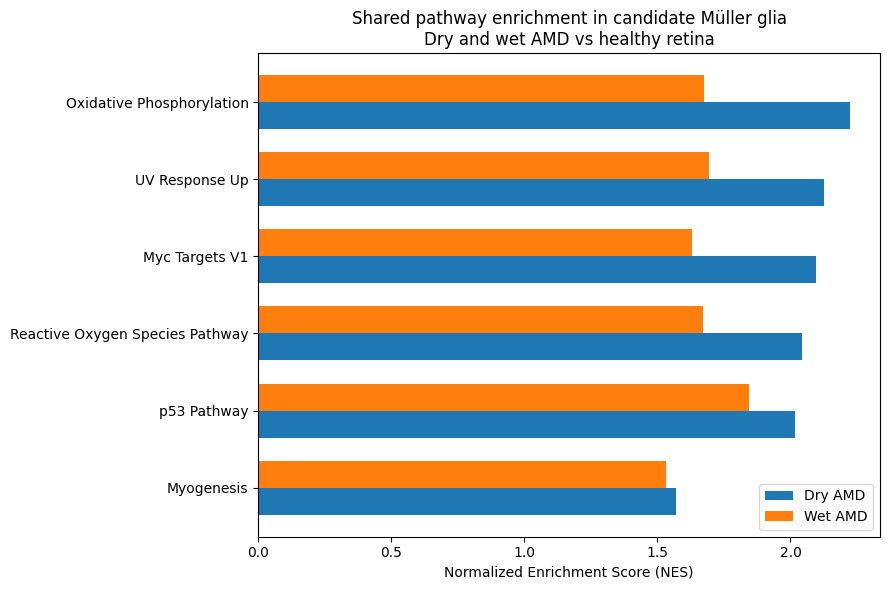

In [24]:
plot_df = shared.sort_values("NES_dry", ascending=True).copy()

y = np.arange(len(plot_df))
height = 0.35

plt.figure(figsize=(9, 6))

plt.barh(
    y - height/2,
    plot_df["NES_dry"],
    height,
    label="Dry AMD"
)

plt.barh(
    y + height/2,
    plot_df["NES_wet"],
    height,
    label="Wet AMD"
)

plt.yticks(y, plot_df["Term"])
plt.xlabel("Normalized Enrichment Score (NES)")
plt.title(
    "Shared pathway enrichment in candidate Müller glia\n"
    "Dry and wet AMD vs healthy retina"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "shared_AMD_Muller_pathways_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
dry_results.to_csv(
    "dry_AMD_vs_healthy_DE.csv"
)

wet_results.to_csv(
    "wet_AMD_vs_healthy_DE.csv"
)

dry_pathways.to_csv(
    "dry_AMD_GSEA.csv",
    index=False
)

wet_pathways.to_csv(
    "wet_AMD_GSEA.csv",
    index=False
)

shared.to_csv(
    "shared_significant_pathways.csv",
    index=False
)

pseudo_meta_filt.to_csv(
    "Muller_pseudobulk_sample_metadata.csv",
    index=False
)

print("All project outputs saved.")

All project outputs saved.
